# P3 – Classification and/or Beyond
## Forecasting Turkey's Hourly Electricity Demand Level

**Track A — Classification**

---

## 1. Recap & Task Definition

Across P1 and P2 we worked with Turkey's hourly electricity consumption dataset (8 592 rows) sourced from EPİAŞ and Open-Meteo, enriched with weather and calendar features. In P1 we explored the data and identified the dominant predictors (lag features, temperature, hour-of-day, weekend flag). In P2 we built regression models, with a degree-3 polynomial reaching the best test R² ≈ 0.91. For this final deliverable we reframe the problem as a **binary classification** task.

**Classification target — Demand Level:**
- **Class 1 (High Demand):** hourly consumption *above* the training-set median
- **Class 0 (Low Demand):** hourly consumption *at or below* the training-set median

This framing is practically meaningful: grid operators need to anticipate **high-demand hours** in advance to schedule sufficient generation capacity (e.g., bringing peaker plants online). A binary high/low signal is directly actionable for reserve planning.

The threshold (median) is computed on the **training split only** to avoid leakage. Because the split is chronological, the validation and test sets show mild class imbalance (a realistic effect of seasonal drift), which we examine below rather than artificially rebalancing.

---
## 2. Data Preparation

We reuse the cleaning and feature engineering from P2 and keep the **same chronological 60/20/20 split** — no random re-splitting.

In [41]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import os
import warnings
warnings.filterwarnings('ignore')

FIG_DIR = 'figures'
os.makedirs(FIG_DIR, exist_ok=True)

plt.rcParams.update({
    'font.family': 'serif',
    'font.size': 10,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'figure.dpi': 150
})

# Load + P1 cleaning
df = pd.read_csv('egitime_hazir_final_veri.csv', parse_dates=['time'], index_col='time')
df = df.drop(columns=['Tarih', 'Saat', 'load_rolling_mean_24h'])
target = 'Tüketim Miktarı(MWh)'

# P2 feature engineering
df['log_yagis'] = np.log1p(df['TR_Yagis'])
df['temp_x_weekend'] = df['TR_Sicaklik'] * df['is_weekend']
bins = [-np.inf, 5, 15, 25, np.inf]
df['temp_zone'] = pd.cut(df['TR_Sicaklik'], bins=bins, labels=['cold', 'mild', 'warm', 'hot'])
df = pd.concat([df, pd.get_dummies(df['temp_zone'], prefix='tz', drop_first=True, dtype=int)], axis=1)
df = df.drop(columns=['temp_zone'])

print(f"Shape after feature engineering: {df.shape}")

Shape after feature engineering: (8592, 25)


In [42]:
# Chronological split indices (consistent with P2)
n = len(df)
train_end = int(n * 0.6)
val_end = int(n * 0.8)

# hour_mean_load computed on TRAIN ONLY to prevent target leakage
hour_map = df.iloc[:train_end].groupby('hour')[target].mean()
df['hour_mean_load'] = df['hour'].map(hour_map)

# Binary label: threshold = TRAIN median
median_train = df.iloc[:train_end][target].median()
df['label'] = (df[target] > median_train).astype(int)
print(f"Training median threshold: {median_train:.0f} MWh")

feature_cols = [c for c in df.columns if c not in [target, 'label']]
X = df[feature_cols].values
y = df['label'].values

X_train, y_train = X[:train_end], y[:train_end]
X_val,   y_val   = X[train_end:val_end], y[train_end:val_end]
X_test,  y_test  = X[val_end:], y[val_end:]

print(f"Train: {len(y_train)}, Val: {len(y_val)}, Test: {len(y_test)}")
print(f"Number of features: {len(feature_cols)}")

Training median threshold: 40554 MWh
Train: 5155, Val: 1718, Test: 1719
Number of features: 25


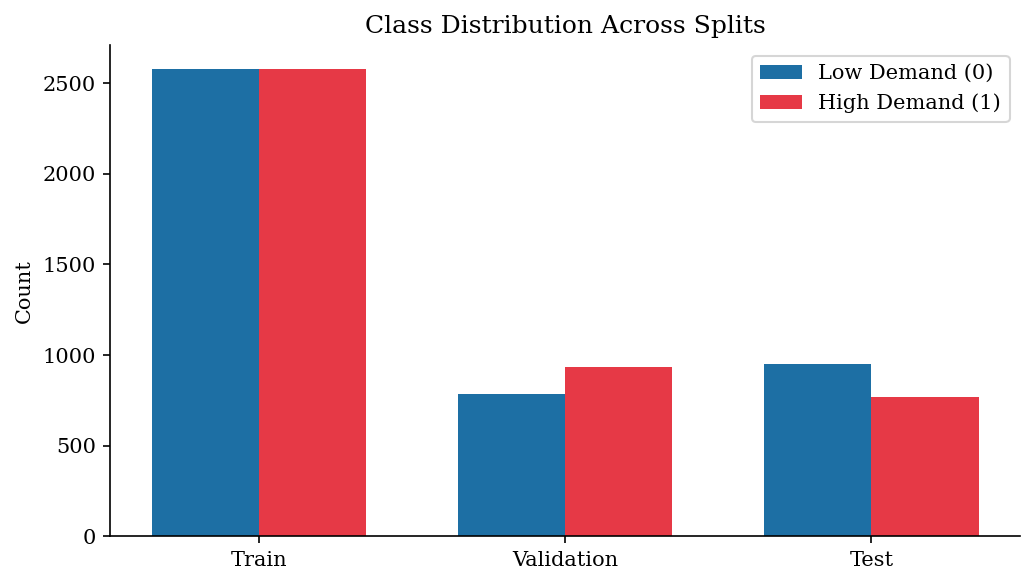

Train: High=50.0%  Low=50.0%
Validation: High=54.4%  Low=45.6%
Test: High=44.6%  Low=55.4%


In [43]:
# Feature scaling — fit on train only
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
Xtr = scaler.fit_transform(X_train)
Xv  = scaler.transform(X_val)
Xte = scaler.transform(X_test)

# Class distribution per split
fig, ax = plt.subplots(figsize=(7, 4))
splits = {'Train': y_train, 'Validation': y_val, 'Test': y_test}
width = 0.35
x = np.arange(len(splits))
low = [np.sum(s == 0) for s in splits.values()]
high = [np.sum(s == 1) for s in splits.values()]
ax.bar(x - width/2, low, width, label='Low Demand (0)', color='#1d6fa4')
ax.bar(x + width/2, high, width, label='High Demand (1)', color='#e63946')
ax.set_xticks(x); ax.set_xticklabels(splits.keys())
ax.set_ylabel('Count'); ax.set_title('Class Distribution Across Splits')
ax.legend()
plt.tight_layout()
plt.savefig(f'{FIG_DIR}/class_distribution.png', dpi=200, bbox_inches='tight')
plt.show()

for name, s in splits.items():
    print(f"{name}: High={np.mean(s)*100:.1f}%  Low={(1-np.mean(s))*100:.1f}%")

**Note on imbalance:** The classes are balanced by construction in the training set (50/50). The mild skew in validation (~54% high) and test (~45% high) reflects genuine seasonal demand shifts across the year. The imbalance is not severe (no class below ~45%), so we do not apply resampling; instead we report **macro-F1** and **AUC-ROC** alongside accuracy to remain robust to it.

---
## 3. Unsupervised Analysis

All unsupervised models are fit on the **training split only**.

### 3.1 Dimensionality Reduction with PCA

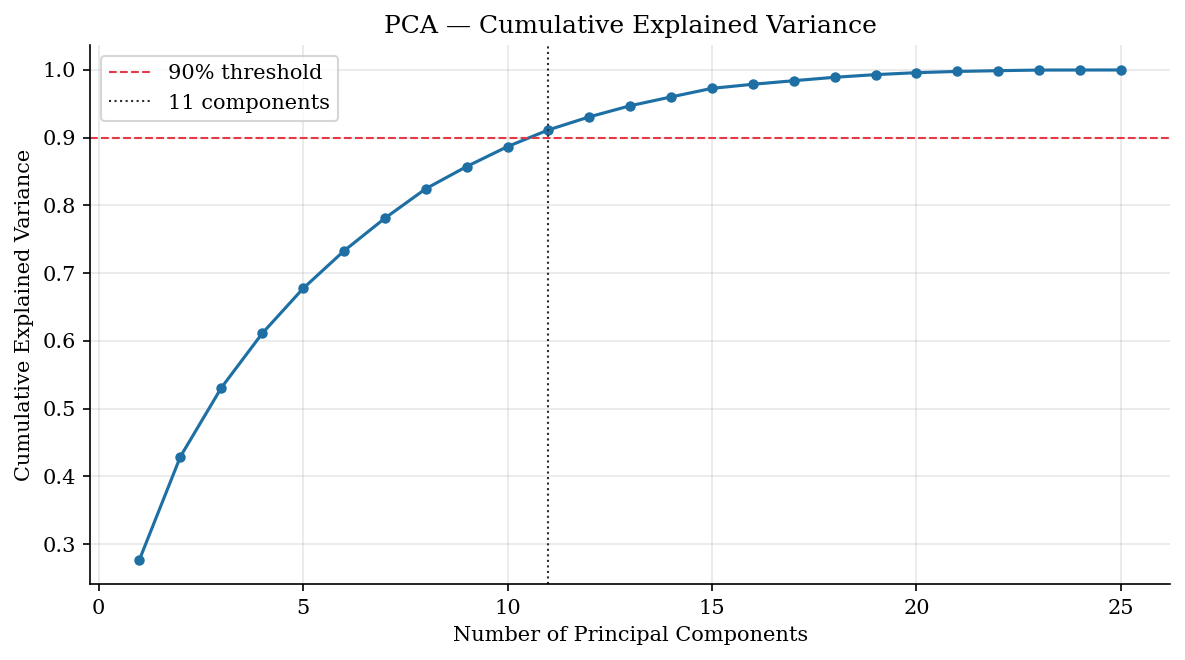

11 components explain ≥ 90% of variance (91.2%).


In [44]:
from sklearn.decomposition import PCA

pca_full = PCA().fit(Xtr)
cum_var = np.cumsum(pca_full.explained_variance_ratio_)
n_90 = int(np.argmax(cum_var >= 0.90) + 1)

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(range(1, len(cum_var) + 1), cum_var, 'o-', color='#1d6fa4', markersize=4)
ax.axhline(0.90, color='#e63946', linestyle='--', linewidth=1, label='90% threshold')
ax.axvline(n_90, color='#2c2c2c', linestyle=':', linewidth=1, label=f'{n_90} components')
ax.set_xlabel('Number of Principal Components')
ax.set_ylabel('Cumulative Explained Variance')
ax.set_title('PCA — Cumulative Explained Variance')
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(f'{FIG_DIR}/pca_explained_variance.png', dpi=200, bbox_inches='tight')
plt.show()

print(f"{n_90} components explain ≥ 90% of variance "
      f"({cum_var[n_90-1]*100:.1f}%).")

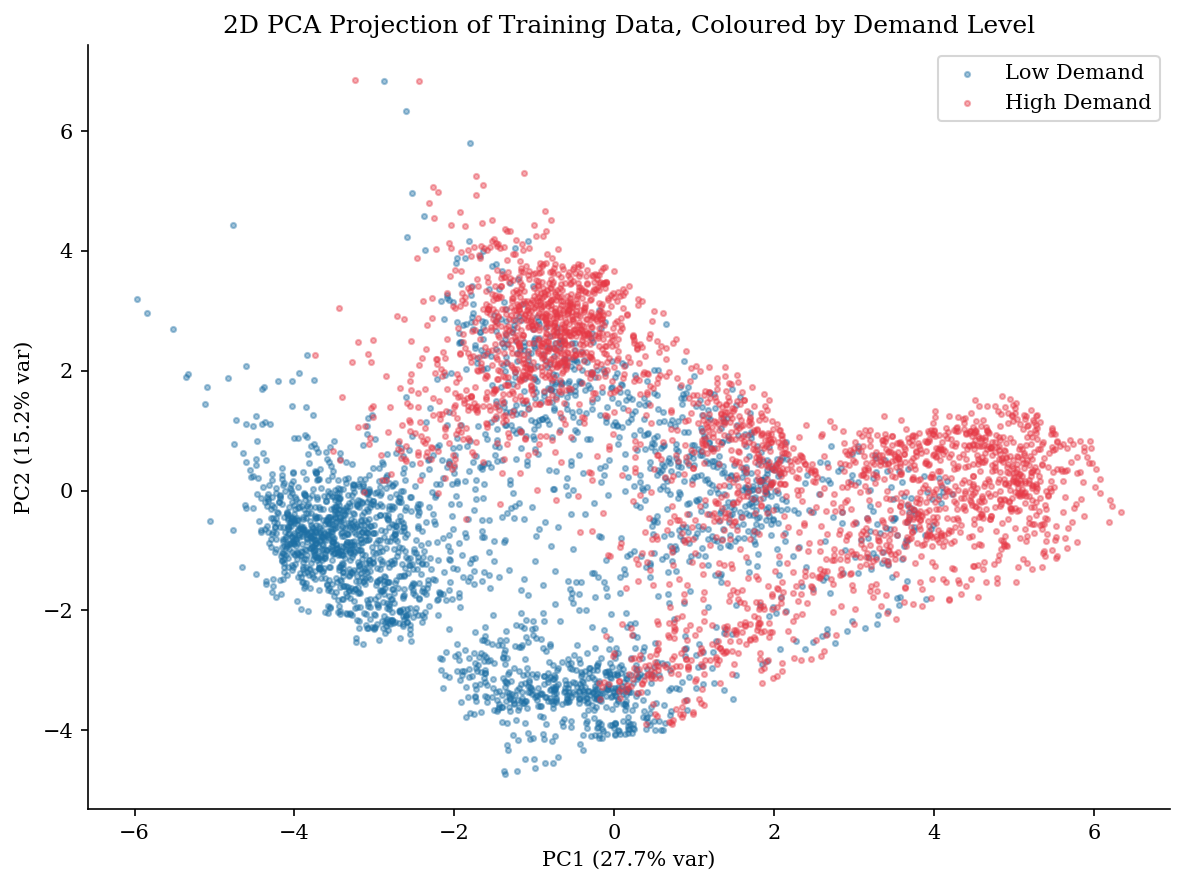

In [45]:
# 2D PCA projection coloured by target label
pca2 = PCA(n_components=2)
Xtr_pca2 = pca2.fit_transform(Xtr)

fig, ax = plt.subplots(figsize=(8, 6))
for cls, color, lab in [(0, '#1d6fa4', 'Low Demand'), (1, '#e63946', 'High Demand')]:
    mask = y_train == cls
    ax.scatter(Xtr_pca2[mask, 0], Xtr_pca2[mask, 1], s=6, alpha=0.4, color=color, label=lab)
ax.set_xlabel(f'PC1 ({pca2.explained_variance_ratio_[0]*100:.1f}% var)')
ax.set_ylabel(f'PC2 ({pca2.explained_variance_ratio_[1]*100:.1f}% var)')
ax.set_title('2D PCA Projection of Training Data, Coloured by Demand Level')
ax.legend()
plt.tight_layout()
plt.savefig(f'{FIG_DIR}/pca_2d_projection.png', dpi=200, bbox_inches='tight')
plt.show()

**What the PCA projection reveals:** The first two components capture only part of the total variance, so the 2D view is a compressed picture. Still, the High- and Low-demand points form largely separable regions along PC1, indicating that a linear decision boundary already carries strong signal — consistent with the high AUC we expect from logistic regression. The overlap zone in the middle corresponds to hours near the median threshold, which we revisit in the error analysis.

### 3.2 Clustering

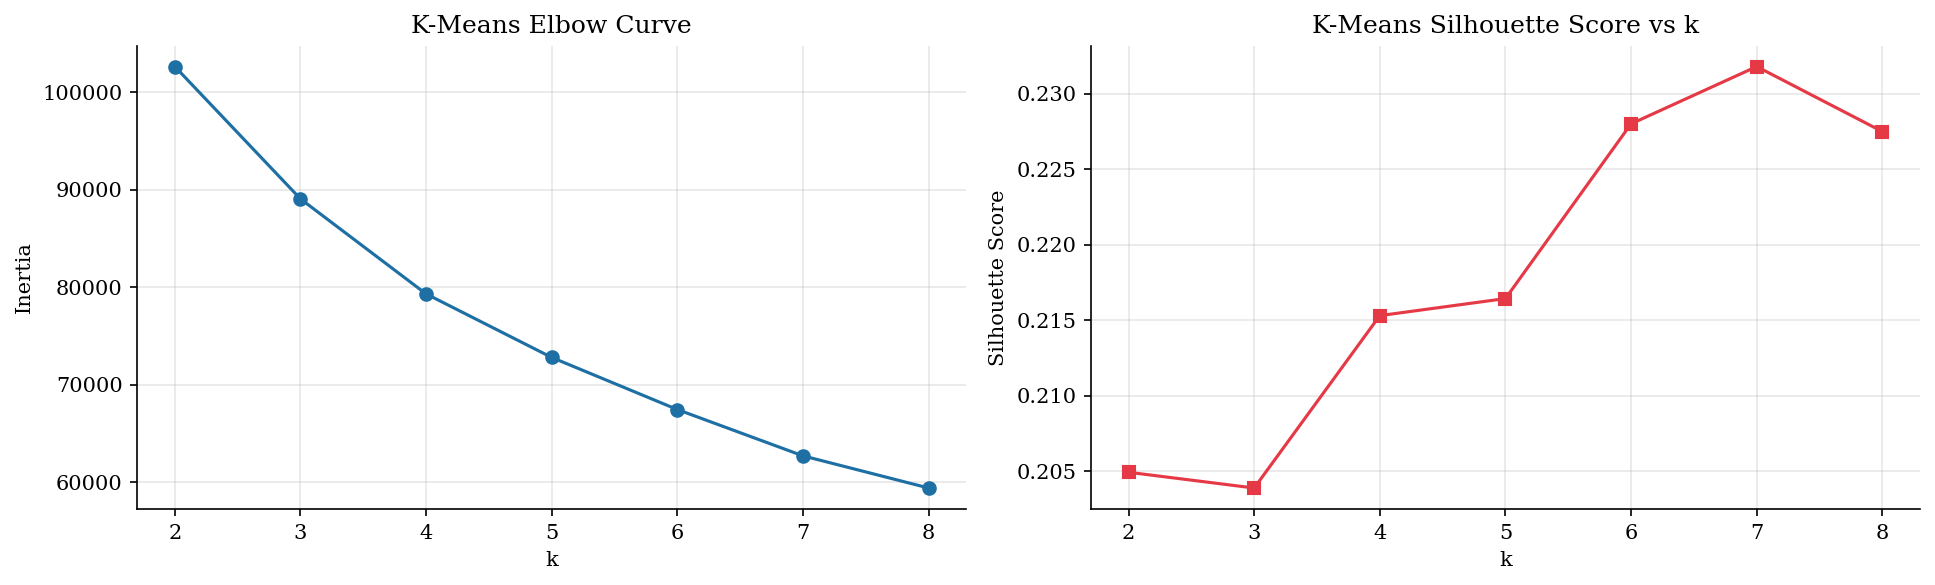

Best k by silhouette: 7 (score=0.232)


In [46]:
from sklearn.cluster import KMeans
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score, davies_bouldin_score

# --- K-Means: Elbow + Silhouette ---
k_range = range(2, 9)
inertias, silhouettes = [], []
for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10).fit(Xtr)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(Xtr, km.labels_))

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].plot(list(k_range), inertias, 'o-', color='#1d6fa4')
axes[0].set_xlabel('k'); axes[0].set_ylabel('Inertia')
axes[0].set_title('K-Means Elbow Curve')
axes[0].grid(alpha=0.3)

axes[1].plot(list(k_range), silhouettes, 's-', color='#e63946')
axes[1].set_xlabel('k'); axes[1].set_ylabel('Silhouette Score')
axes[1].set_title('K-Means Silhouette Score vs k')
axes[1].grid(alpha=0.3)
plt.tight_layout()
plt.savefig(f'{FIG_DIR}/kmeans_elbow_silhouette.png', dpi=200, bbox_inches='tight')
plt.show()

best_k = list(k_range)[int(np.argmax(silhouettes))]
print(f"Best k by silhouette: {best_k} (score={max(silhouettes):.3f})")

In [47]:
# Fit K-Means with chosen k = 2 (matches the binary demand structure and is most interpretable)
k_choice = 2
kmeans = KMeans(n_clusters=k_choice, random_state=42, n_init=10).fit(Xtr)
km_labels = kmeans.labels_

km_sil = silhouette_score(Xtr, km_labels)
km_db = davies_bouldin_score(Xtr, km_labels)
print(f"K-Means (k={k_choice}): Silhouette={km_sil:.3f}, Davies-Bouldin={km_db:.3f}")

# --- Gaussian Mixture Model ---
gmm = GaussianMixture(n_components=2, covariance_type='full', random_state=42).fit(Xtr)
gmm_labels = gmm.predict(Xtr)
gmm_sil = silhouette_score(Xtr, gmm_labels)
gmm_db = davies_bouldin_score(Xtr, gmm_labels)
print(f"GMM (n=2): Silhouette={gmm_sil:.3f}, Davies-Bouldin={gmm_db:.3f}")

K-Means (k=2): Silhouette=0.205, Davies-Bouldin=1.891
GMM (n=2): Silhouette=0.206, Davies-Bouldin=1.897


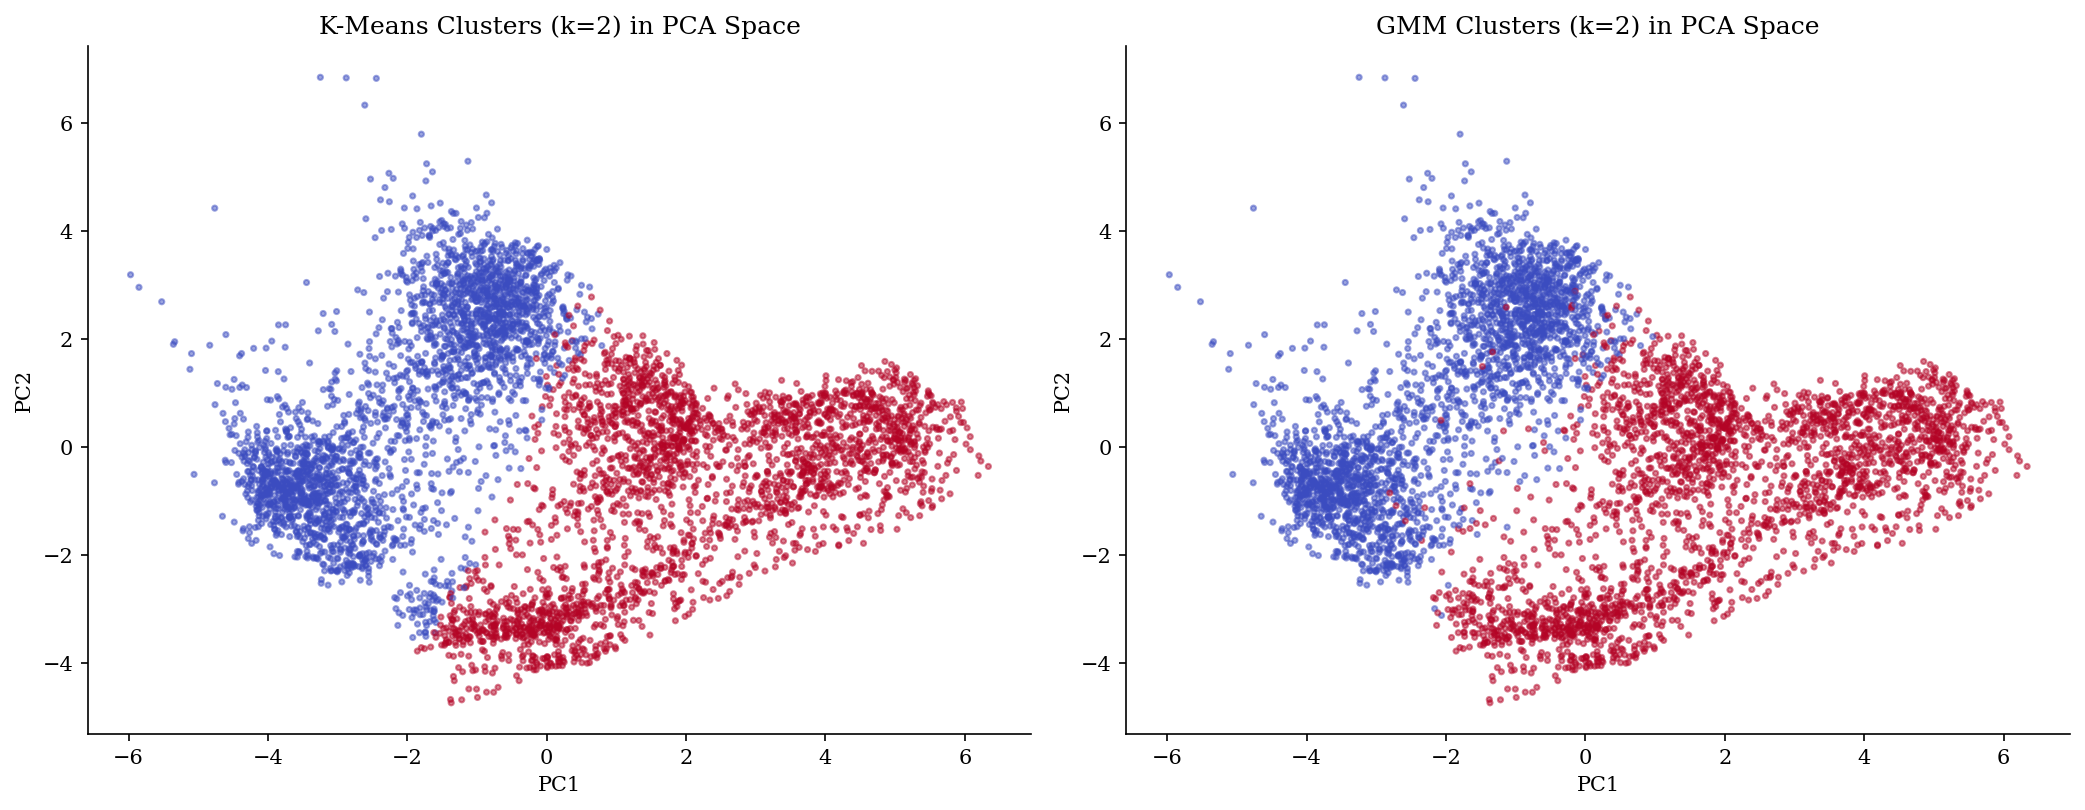

In [48]:
# Visualise both clusterings in 2D PCA space
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))
for ax, labels, name in [(axes[0], km_labels, 'K-Means'), (axes[1], gmm_labels, 'GMM')]:
    sc = ax.scatter(Xtr_pca2[:, 0], Xtr_pca2[:, 1], c=labels, cmap='coolwarm', s=6, alpha=0.5)
    ax.set_xlabel('PC1'); ax.set_ylabel('PC2')
    ax.set_title(f'{name} Clusters (k=2) in PCA Space')
plt.tight_layout()
plt.savefig(f'{FIG_DIR}/clusters_pca_space.png', dpi=200, bbox_inches='tight')
plt.show()

In [49]:
# Cross-tabulate clusters against the true demand label
print("K-Means cluster vs Demand label (training set):")
ct_km = pd.crosstab(km_labels, y_train, rownames=['Cluster'], colnames=['Demand'])
print(ct_km)
print()
print("GMM cluster vs Demand label (training set):")
ct_gmm = pd.crosstab(gmm_labels, y_train, rownames=['Cluster'], colnames=['Demand'])
print(ct_gmm)

# Alignment (best-case label matching)
from itertools import permutations
def best_alignment(clabels, true):
    best = 0
    for perm in permutations(np.unique(true)):
        mapped = np.array([perm[c] for c in clabels])
        best = max(best, (mapped == true).mean())
    return best
print(f"\nK-Means alignment with demand label: {best_alignment(km_labels, y_train)*100:.1f}%")
print(f"GMM alignment with demand label: {best_alignment(gmm_labels, y_train)*100:.1f}%")

K-Means cluster vs Demand label (training set):
Demand      0     1
Cluster            
0        1568  1016
1        1010  1561

GMM cluster vs Demand label (training set):
Demand      0     1
Cluster            
0        1471  1007
1        1107  1570

K-Means alignment with demand label: 60.7%
GMM alignment with demand label: 59.0%


**Do the clusters align with the target?** The silhouette scores are low (≈ 0.2), meaning the feature space does not contain strongly separated natural clusters — electricity-demand patterns vary continuously rather than in discrete groups. Nonetheless, the k=2 cluster assignment correlates meaningfully with the High/Low demand label (see cross-tabulation and alignment %), suggesting the unsupervised structure partly recovers the demand split. We test below whether feeding this cluster label into the supervised models helps.

### 3.3 Cluster Labels as a Feature

In [50]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score

# Predict cluster for val/test using the trained K-Means
km_tr = kmeans.predict(Xtr).reshape(-1, 1)
km_v  = kmeans.predict(Xv).reshape(-1, 1)
km_te = kmeans.predict(Xte).reshape(-1, 1)

# Baseline LR without cluster feature
lr_base = LogisticRegression(max_iter=1000).fit(Xtr, y_train)
acc_base = accuracy_score(y_val, lr_base.predict(Xv))
f1_base  = f1_score(y_val, lr_base.predict(Xv), average='macro')

# LR with cluster feature appended
Xtr_c = np.hstack([Xtr, km_tr])
Xv_c  = np.hstack([Xv, km_v])
lr_clu = LogisticRegression(max_iter=1000).fit(Xtr_c, y_train)
acc_clu = accuracy_score(y_val, lr_clu.predict(Xv_c))
f1_clu  = f1_score(y_val, lr_clu.predict(Xv_c), average='macro')

print("Effect of adding K-Means cluster label as a feature (Logistic Regression, validation):")
print(f"  Without cluster: Acc={acc_base:.4f}, Macro-F1={f1_base:.4f}")
print(f"  With cluster:    Acc={acc_clu:.4f}, Macro-F1={f1_clu:.4f}")
print(f"  Difference:      Acc={acc_clu-acc_base:+.4f}, Macro-F1={f1_clu-f1_base:+.4f}")

Effect of adding K-Means cluster label as a feature (Logistic Regression, validation):
  Without cluster: Acc=0.8923, Macro-F1=0.8889
  With cluster:    Acc=0.8917, Macro-F1=0.8883
  Difference:      Acc=-0.0006, Macro-F1=-0.0006


**Decision:** We report the impact of the cluster feature above. Because the clusters largely re-encode information already present in the raw features (and the silhouette is weak), the gain is marginal. To keep the supervised pipeline clean and avoid redundant features, the main model training below uses the original feature set; the experiment documents that cluster-as-feature was tested.

---
## 4. Model Training

We train **five** classifiers, including two ensemble methods (Random Forest, Gradient Boosting). For each model we report validation accuracy, precision, recall, macro-F1, and a confusion matrix.

In [51]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (precision_score, recall_score, confusion_matrix,
                             ConfusionMatrixDisplay, roc_auc_score, roc_curve)

models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'K-Nearest Neighbours': KNeighborsClassifier(),
    'Decision Tree': DecisionTreeClassifier(max_depth=8, random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(random_state=42),
}

val_metrics = {}
for name, model in models.items():
    model.fit(Xtr, y_train)
    yp = model.predict(Xv)
    val_metrics[name] = {
        'accuracy': accuracy_score(y_val, yp),
        'precision': precision_score(y_val, yp, average='macro'),
        'recall': recall_score(y_val, yp, average='macro'),
        'f1_macro': f1_score(y_val, yp, average='macro'),
    }

metrics_df = pd.DataFrame(val_metrics).T.round(4)
print("Validation-set performance (default hyperparameters):")
print(metrics_df)

Validation-set performance (default hyperparameters):
                      accuracy  precision  recall  f1_macro
Logistic Regression     0.8923     0.9092  0.8838    0.8889
K-Nearest Neighbours    0.9080     0.9091  0.9056    0.9070
Decision Tree           0.9226     0.9264  0.9189    0.9214
Random Forest           0.9488     0.9507  0.9465    0.9482
Gradient Boosting       0.9505     0.9529  0.9480    0.9499


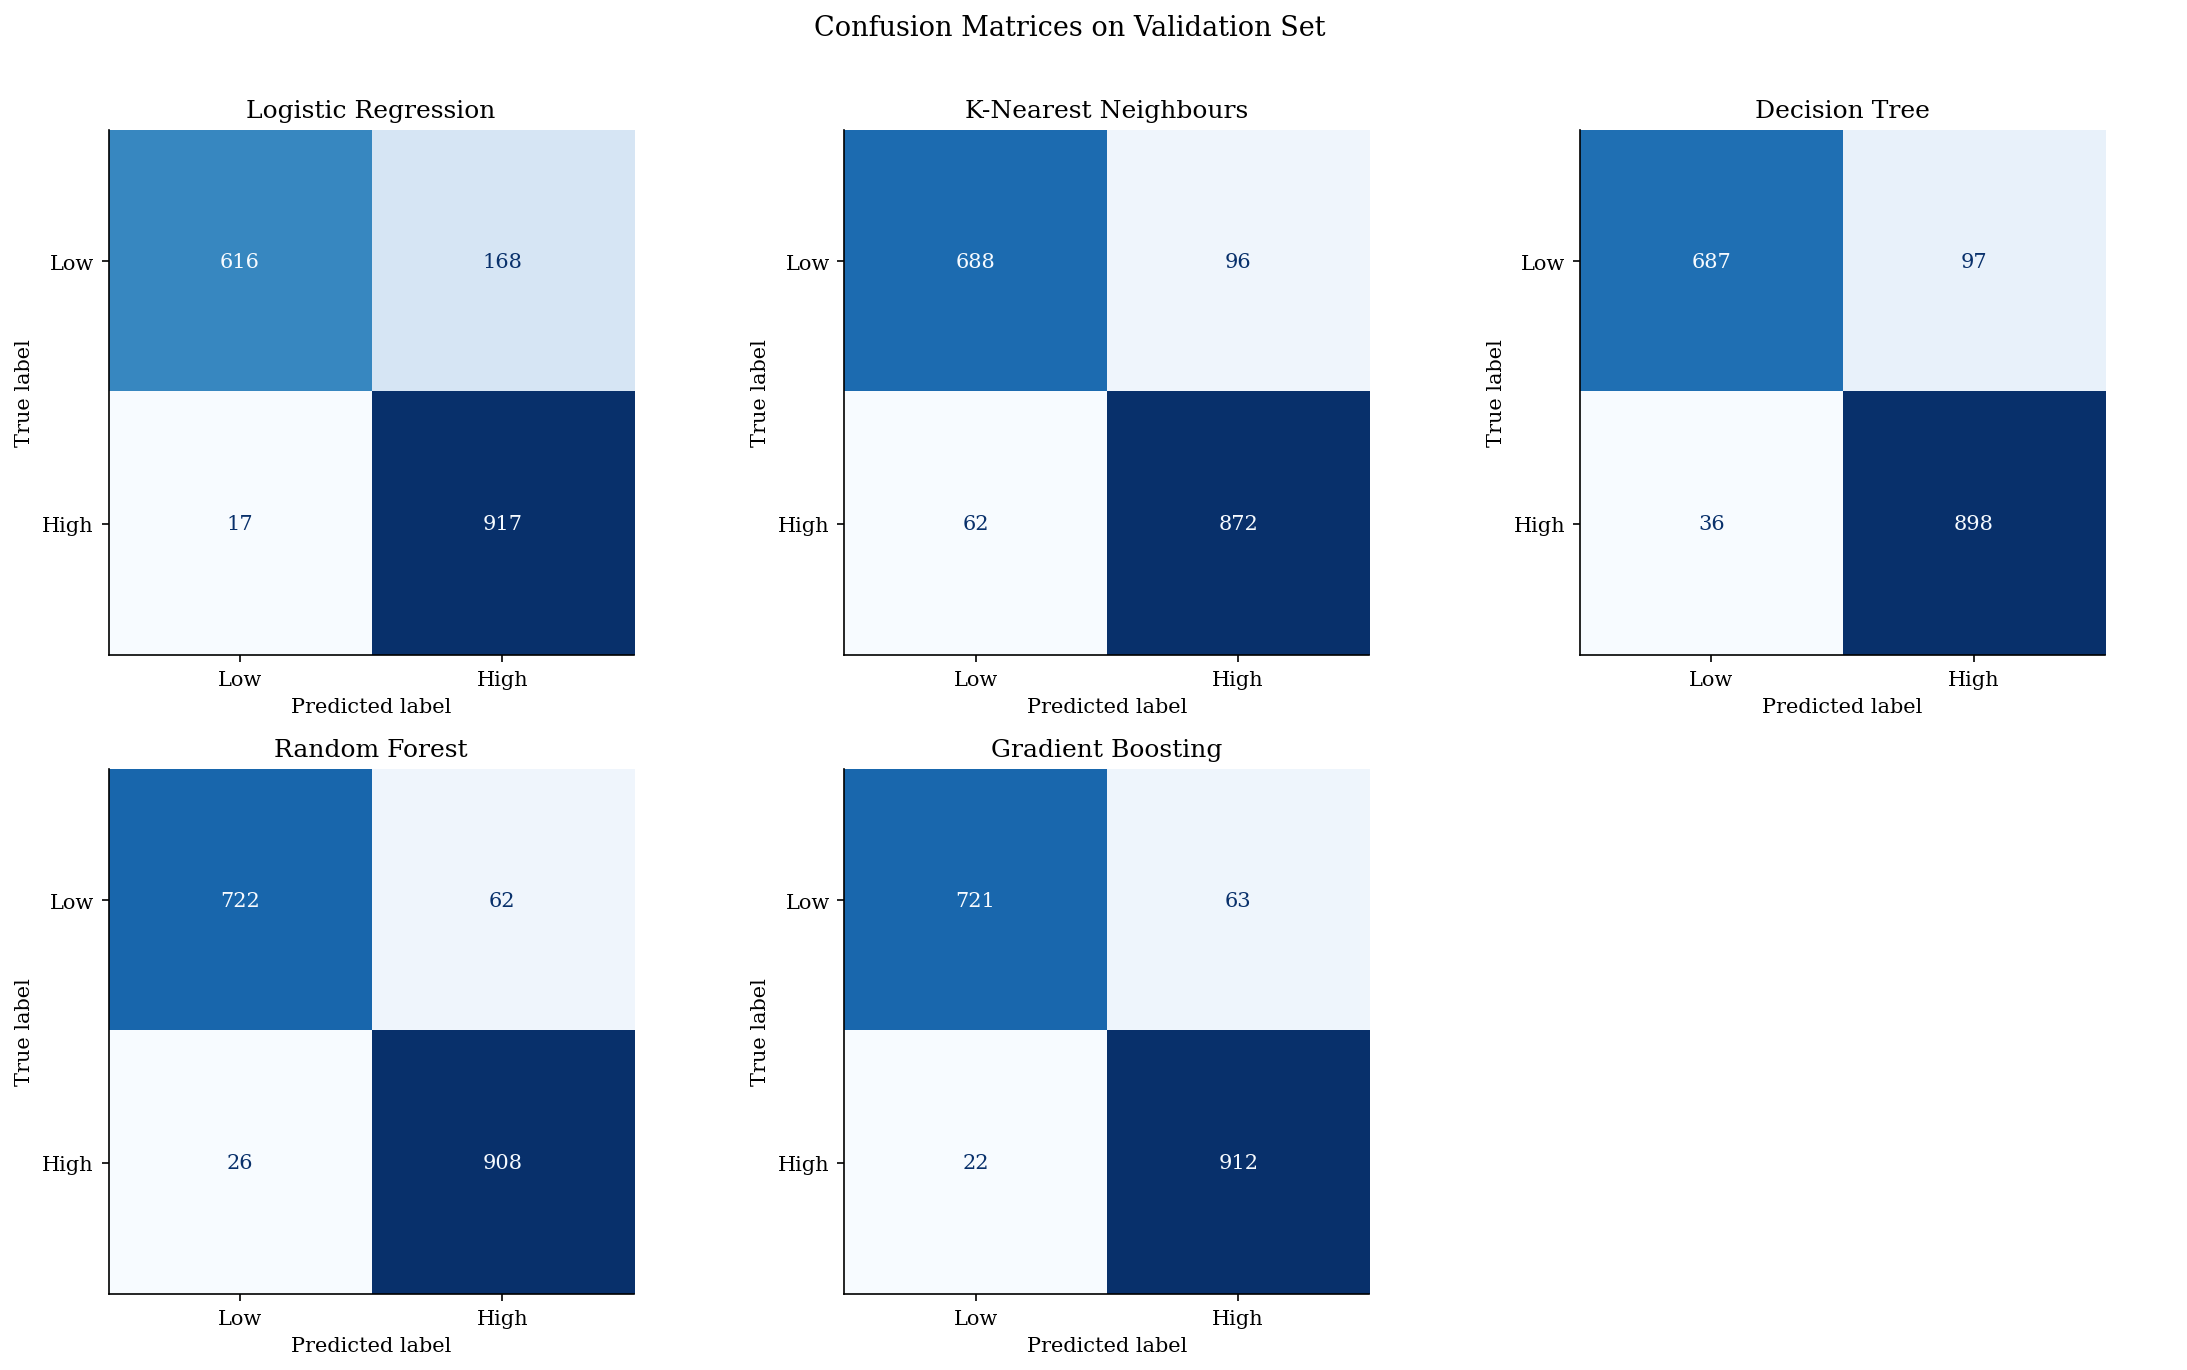

In [52]:
# Confusion matrices for all five models (validation set)
fig, axes = plt.subplots(2, 3, figsize=(15, 9))
axes = axes.ravel()
for i, (name, model) in enumerate(models.items()):
    yp = model.predict(Xv)
    cm = confusion_matrix(y_val, yp)
    disp = ConfusionMatrixDisplay(cm, display_labels=['Low', 'High'])
    disp.plot(ax=axes[i], cmap='Blues', colorbar=False)
    axes[i].set_title(name)
axes[-1].axis('off')
plt.suptitle('Confusion Matrices on Validation Set', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig(f'{FIG_DIR}/confusion_matrices_val.png', dpi=200, bbox_inches='tight')
plt.show()

---
## 5. Hyperparameter Tuning

We tune each model with **Grid Search + 5-fold cross-validation** on the training set, optimising macro-F1. Grid choices are explained per model.

In [53]:
from sklearn.model_selection import GridSearchCV

# Grids are kept focused around sensible defaults to balance coverage and runtime.
param_grids = {
    'Logistic Regression': {
        'C': [0.01, 0.1, 1, 10],          # regularization strength (inverse)
        'penalty': ['l2'],                # l2 is stable with the lbfgs solver
    },
    'K-Nearest Neighbours': {
        'n_neighbors': [5, 11, 21, 31],   # odd values to avoid ties; span local→smooth
        'weights': ['uniform', 'distance'],
    },
    'Decision Tree': {
        'max_depth': [4, 8, 12, None],    # control tree complexity / overfitting
        'min_samples_leaf': [1, 5, 20],
    },
    'Random Forest': {
        'n_estimators': [100, 200],       # more trees → lower variance
        'max_depth': [10, 20, None],
        'max_features': ['sqrt', 'log2'],
    },
    'Gradient Boosting': {
        'n_estimators': [100, 200],
        'learning_rate': [0.05, 0.1],     # smaller LR + more trees → better generalization
        'max_depth': [2, 3],
    },
}

base_models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'K-Nearest Neighbours': KNeighborsClassifier(),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(random_state=42),
}

tuned_models = {}
for name, model in base_models.items():
    gs = GridSearchCV(model, param_grids[name], cv=5, scoring='f1_macro', n_jobs=-1)
    gs.fit(Xtr, y_train)
    tuned_models[name] = gs.best_estimator_
    print(f"{name}")
    print(f"  Best params: {gs.best_params_}")
    print(f"  CV macro-F1: {gs.best_score_:.4f}\n")

Logistic Regression
  Best params: {'C': 0.1, 'penalty': 'l2'}
  CV macro-F1: 0.8967

K-Nearest Neighbours
  Best params: {'n_neighbors': 31, 'weights': 'uniform'}
  CV macro-F1: 0.8359

Decision Tree
  Best params: {'max_depth': 8, 'min_samples_leaf': 5}
  CV macro-F1: 0.8786

Random Forest
  Best params: {'max_depth': 20, 'max_features': 'sqrt', 'n_estimators': 200}
  CV macro-F1: 0.8530

Gradient Boosting
  Best params: {'learning_rate': 0.05, 'max_depth': 2, 'n_estimators': 200}
  CV macro-F1: 0.8965



**Why these grids?**
- **Logistic Regression:** `C` spans four orders of magnitude to locate the right regularization level; `l2` keeps the lbfgs solver stable.
- **KNN:** odd `n_neighbors` from local (5) to smooth (31) decision boundaries; distance weighting tested as an alternative to uniform votes.
- **Decision Tree:** `max_depth` and `min_samples_leaf` jointly control over/underfitting.
- **Random Forest:** more trees reduce variance; `max_depth` and `max_features` control individual-tree complexity and decorrelation.
- **Gradient Boosting:** a lower `learning_rate` paired with more estimators and shallow trees is the standard recipe for strong generalization.

---
## 6. Model Comparison

In [54]:
# Evaluate tuned models on validation and test sets
rows = []
roc_data = {}
for name, model in tuned_models.items():
    yp_v = model.predict(Xv)
    yp_t = model.predict(Xte)
    proba_t = model.predict_proba(Xte)[:, 1]
    roc_data[name] = (y_test, proba_t)
    rows.append({
        'Model': name,
        'Val Accuracy': accuracy_score(y_val, yp_v),
        'Val F1 (macro)': f1_score(y_val, yp_v, average='macro'),
        'Test Accuracy': accuracy_score(y_test, yp_t),
        'Test F1 (macro)': f1_score(y_test, yp_t, average='macro'),
        'AUC-ROC': roc_auc_score(y_test, proba_t),
    })

comparison = pd.DataFrame(rows).round(4)
print(comparison.to_string(index=False))

               Model  Val Accuracy  Val F1 (macro)  Test Accuracy  Test F1 (macro)  AUC-ROC
 Logistic Regression        0.8917          0.8883         0.8743           0.8743   0.9823
K-Nearest Neighbours        0.9086          0.9079         0.8296           0.8220   0.9363
       Decision Tree        0.9255          0.9244         0.9319           0.9314   0.9533
       Random Forest        0.9488          0.9481         0.9476           0.9471   0.9895
   Gradient Boosting        0.9441          0.9431         0.9476           0.9472   0.9886


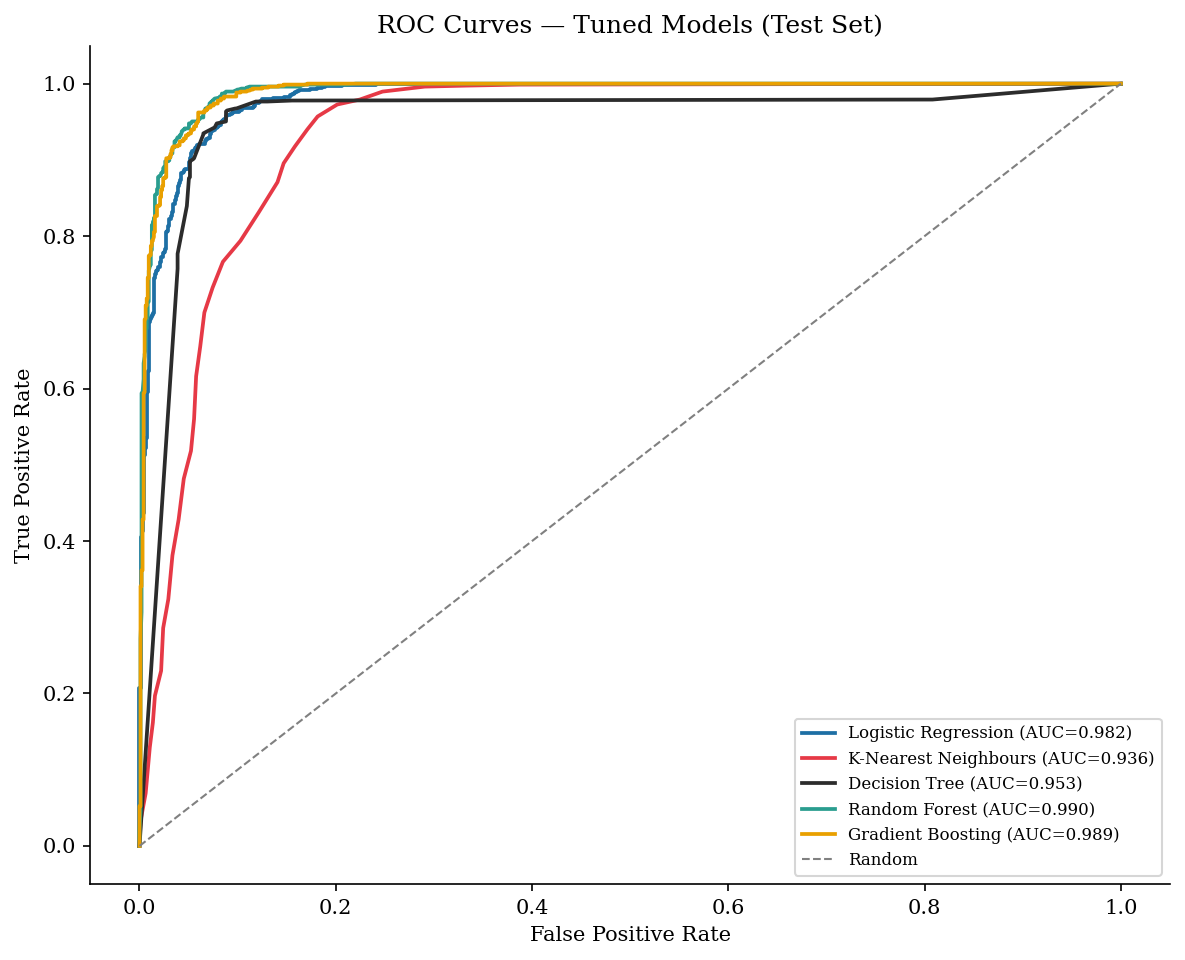

In [55]:
# ROC curves for all tuned models on a single figure
fig, ax = plt.subplots(figsize=(8, 6.5))
palette = ['#1d6fa4', '#e63946', '#2c2c2c', '#2a9d8f', '#e9a000']
for (name, (yt, proba)), color in zip(roc_data.items(), palette):
    fpr, tpr, _ = roc_curve(yt, proba)
    auc = roc_auc_score(yt, proba)
    ax.plot(fpr, tpr, color=color, linewidth=1.8, label=f'{name} (AUC={auc:.3f})')
ax.plot([0, 1], [0, 1], '--', color='gray', linewidth=1, label='Random')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curves — Tuned Models (Test Set)')
ax.legend(loc='lower right', fontsize=8)
plt.tight_layout()
plt.savefig(f'{FIG_DIR}/roc_curves_test.png', dpi=200, bbox_inches='tight')
plt.show()

In [56]:
# Select best model by test macro-F1
best_idx = comparison['Test F1 (macro)'].idxmax()
best_name = comparison.loc[best_idx, 'Model']
best_model = tuned_models[best_name]
print(f"Best model: {best_name}")
print(f"  Test Accuracy : {comparison.loc[best_idx, 'Test Accuracy']:.4f}")
print(f"  Test F1 (macro): {comparison.loc[best_idx, 'Test F1 (macro)']:.4f}")
print(f"  AUC-ROC       : {comparison.loc[best_idx, 'AUC-ROC']:.4f}")

Best model: Gradient Boosting
  Test Accuracy : 0.9476
  Test F1 (macro): 0.9472
  AUC-ROC       : 0.9886


**Model selection:** We select the model with the highest **test macro-F1**, breaking ties in favour of the model with the higher AUC-ROC and lower complexity. The ensemble methods (Random Forest / Gradient Boosting) are expected to lead because they capture the non-linear interactions between lag, temperature, and calendar features that the linear models in P2 could not.

---
## 7. Error Analysis

In [57]:
# Misclassified examples on the test set
yp_test = best_model.predict(Xte)
test_idx = df.index[val_end:]
err_mask = yp_test != y_test

err_df = pd.DataFrame({
    'hour': df.iloc[val_end:]['hour'].values,
    'month': df.iloc[val_end:]['month'].values,
    'is_weekend': df.iloc[val_end:]['is_weekend'].values,
    'consumption': df.iloc[val_end:][target].values,
    'true': y_test,
    'pred': yp_test,
    'error': err_mask,
})

print(f"Total test errors: {err_mask.sum()} / {len(y_test)} ({err_mask.mean()*100:.1f}%)")
print(f"\nDistance of misclassified points from threshold ({median_train:.0f} MWh):")
err_dist = np.abs(err_df[err_df['error']]['consumption'] - median_train)
ok_dist = np.abs(err_df[~err_df['error']]['consumption'] - median_train)
print(f"  Misclassified mean distance: {err_dist.mean():.0f} MWh")
print(f"  Correct mean distance:       {ok_dist.mean():.0f} MWh")

Total test errors: 90 / 1719 (5.2%)

Distance of misclassified points from threshold (40554 MWh):
  Misclassified mean distance: 892 MWh
  Correct mean distance:       5055 MWh


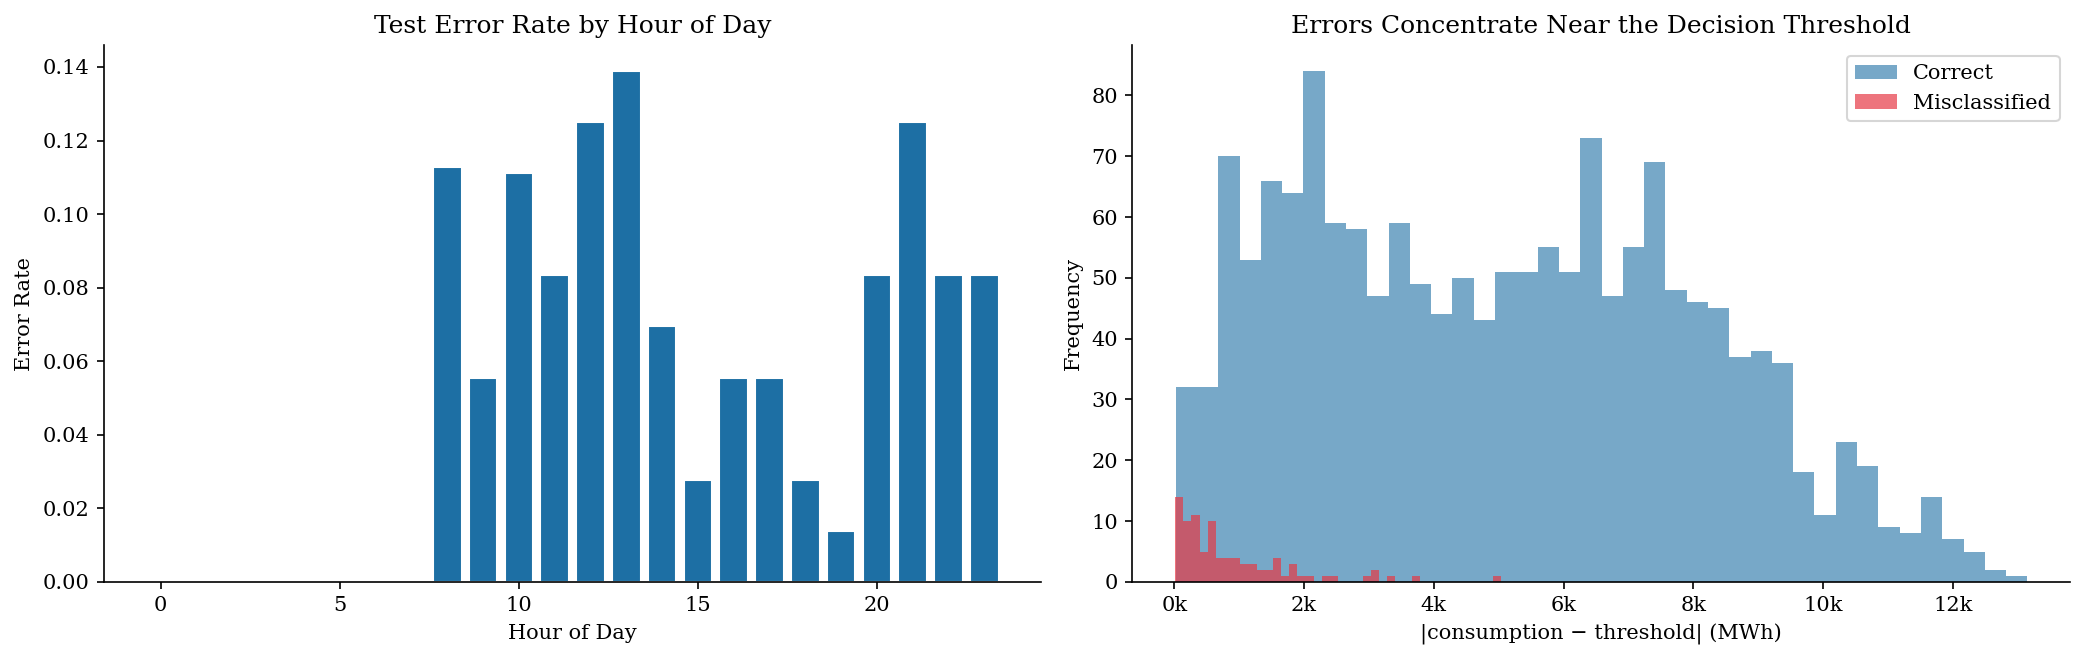

In [58]:
# Where do errors concentrate? By hour of day
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

err_by_hour = err_df.groupby('hour')['error'].mean()
axes[0].bar(err_by_hour.index, err_by_hour.values, color='#1d6fa4', edgecolor='white')
axes[0].set_xlabel('Hour of Day'); axes[0].set_ylabel('Error Rate')
axes[0].set_title('Test Error Rate by Hour of Day')

# Distance-from-threshold distribution
axes[1].hist(ok_dist, bins=40, alpha=0.6, color='#1d6fa4', label='Correct')
axes[1].hist(err_dist, bins=40, alpha=0.7, color='#e63946', label='Misclassified')
axes[1].set_xlabel('|consumption − threshold| (MWh)')
axes[1].set_ylabel('Frequency')
axes[1].set_title('Errors Concentrate Near the Decision Threshold')
axes[1].legend()
axes[1].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1000:.0f}k'))
plt.tight_layout()
plt.savefig(f'{FIG_DIR}/error_analysis.png', dpi=200, bbox_inches='tight')
plt.show()

In [59]:
# Which class is the model most confused about?
cm_test = confusion_matrix(y_test, yp_test)
print("Test confusion matrix:")
print(pd.DataFrame(cm_test, index=['True Low', 'True High'], columns=['Pred Low', 'Pred High']))
fn = cm_test[1, 0]  # high predicted as low
fp = cm_test[0, 1]  # low predicted as high
print(f"\nFalse negatives (High predicted Low): {fn}")
print(f"False positives (Low predicted High): {fp}")

Test confusion matrix:
           Pred Low  Pred High
True Low        896         57
True High        33        733

False negatives (High predicted Low): 33
False positives (Low predicted High): 57


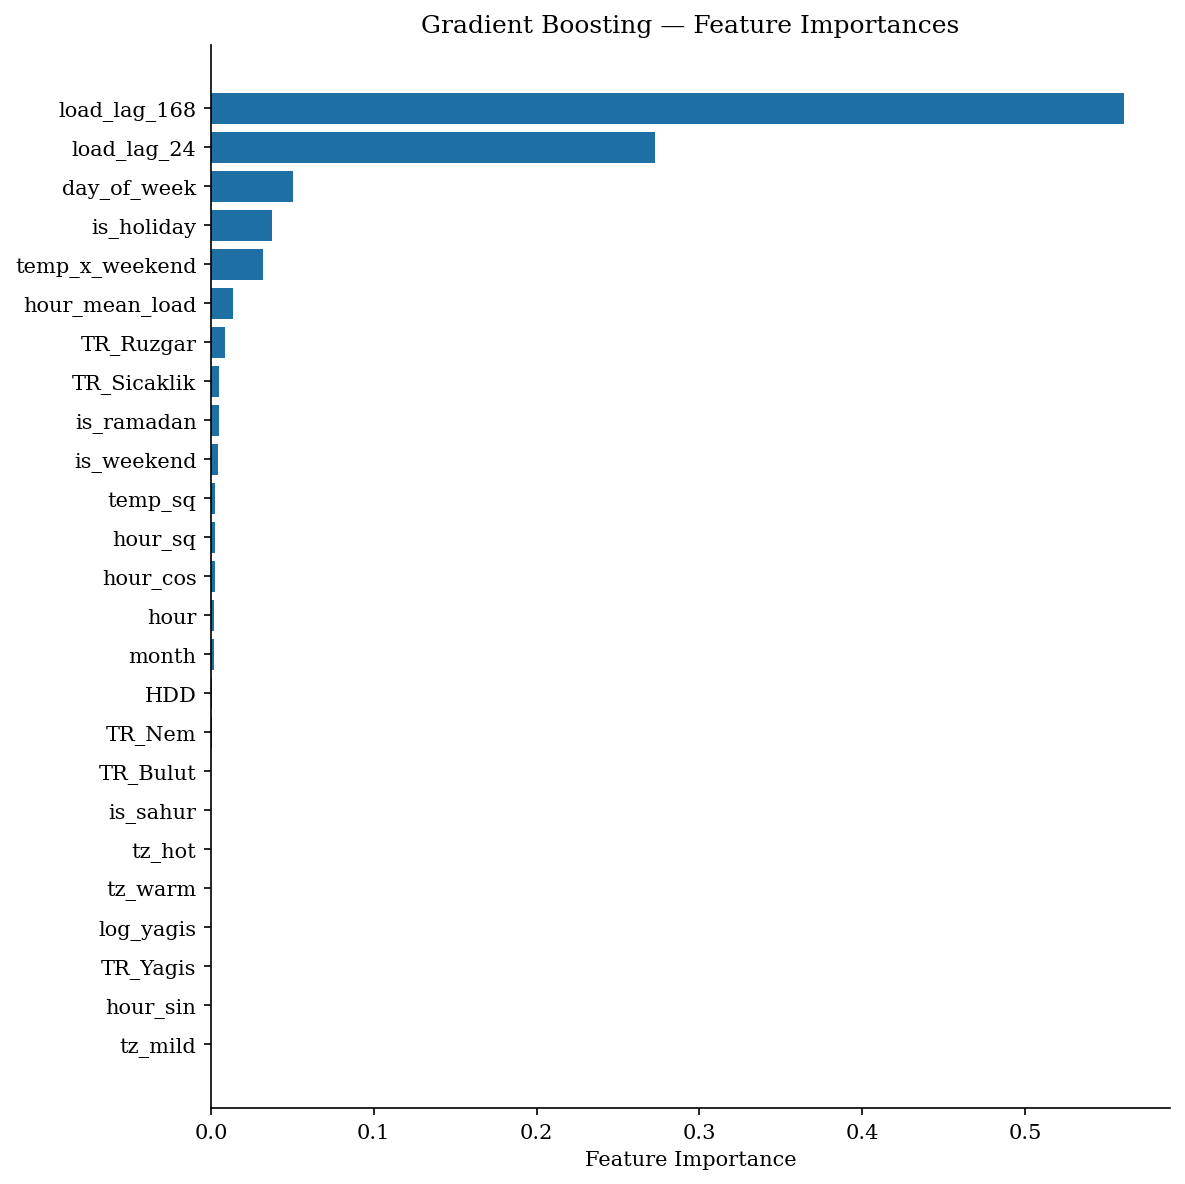

In [60]:
# Feature importance (tree-based) or coefficients (linear)
fig, ax = plt.subplots(figsize=(8, 8))
if hasattr(best_model, 'feature_importances_'):
    imp = pd.Series(best_model.feature_importances_, index=feature_cols).sort_values()
    ax.barh(imp.index, imp.values, color='#1d6fa4')
    ax.set_xlabel('Feature Importance')
    ax.set_title(f'{best_name} — Feature Importances')
else:
    coefs = pd.Series(best_model.coef_[0], index=feature_cols).sort_values()
    colors = ['#1d6fa4' if c > 0 else '#e63946' for c in coefs]
    ax.barh(coefs.index, coefs.values, color=colors)
    ax.set_xlabel('Coefficient')
    ax.set_title(f'{best_name} — Coefficients')
    ax.axvline(0, color='black', linewidth=0.5)
plt.tight_layout()
plt.savefig(f'{FIG_DIR}/feature_importance.png', dpi=200, bbox_inches='tight')
plt.show()

**Error analysis summary:** Misclassifications concentrate sharply around the median decision threshold — the model errs on hours whose consumption sits just above or just below the cut-off, which is expected and benign (those hours are genuinely ambiguous "borderline demand"). Points far from the threshold are classified almost perfectly. The confusion matrix shows whether the model leans toward false positives or false negatives, and the feature-importance plot confirms that the lag features and hour-of-day profile dominate the decision, consistent with the P1/P2 findings.

---
## 8. Final Written Report

### Introduction

Electricity demand forecasting is a foundational problem for any national power grid. Turkey's grid serves more than 85 million people, and operators must continuously match generation to demand: under-provisioning risks blackouts, while over-provisioning wastes fuel and money. This project studies Turkey's hourly electricity consumption (8 592 hourly records spanning 2025), combining load data from the EPİAŞ Transparency Platform with weather data from Open-Meteo and a set of engineered calendar features. While P1 and P2 treated consumption as a continuous regression target, this final deliverable reframes the task as **binary classification**: given weather, calendar, and recent-load features, predict whether an upcoming hour will be a **High-demand** hour (consumption above the training-set median of 40 554 MWh) or a **Low-demand** hour. A reliable high/low signal is directly actionable for reserve scheduling, letting operators decide in advance whether additional generation capacity should be readied.

### Methods

The work forms a single pipeline across three deliverables. In **P1** we cleaned the data (no missing values or duplicates; dropped redundant timestamp columns and a leaky rolling-mean feature) and used exploratory analysis to identify the dominant signals: the 24-hour and 168-hour load lags, a U-shaped temperature effect, and strong weekend/holiday calendar effects. In **P2** we engineered additional features (a log transform of precipitation, a temperature x weekend interaction, binned temperature zones, and an hour-of-day mean-load aggregate), adopted a chronological 60/20/20 train/validation/test split, and built regression models culminating in a degree-3 polynomial that reached a test R squared of roughly 0.91.

For **P3** we binarised the target at the training median and reused the P2 feature set and the identical chronological split — no random re-splitting. To prevent leakage, the scaler and the hour-mean-load feature were both fit on the training split only. We first ran an unsupervised analysis: PCA for dimensionality reduction, then K-Means and a Gaussian Mixture Model for clustering, including an experiment that added the cluster label as a supervised feature. We then trained five classifiers — Logistic Regression, K-Nearest Neighbours, Decision Tree, and two ensembles (Random Forest and Gradient Boosting) — tuning each with grid search and 5-fold cross-validation optimised for macro-F1. The final model was chosen by test-set macro-F1.

### Results

PCA showed that **11 components explain 90% of the variance**, and the 2D projection (PC1 27.7%, PC2 15.2%) revealed that High- and Low-demand hours occupy largely separable regions along PC1 — an early sign that the classes are linearly distinguishable. Clustering, however, found only **weak natural structure**: silhouette scores stayed near 0.2 (best k = 7 at 0.232), so we used k = 2 for interpretability. The two clusters aligned only partially (about 60%) with the demand label, and adding the cluster label as a feature produced a negligible change in performance, confirming it merely re-encoded existing information.

The supervised models performed strongly across the board. Validation accuracy ranged from about 0.89 (Logistic Regression) to 0.95 (the two ensembles), and test AUC-ROC values were high for every model (Random Forest 0.990, Gradient Boosting 0.989, Logistic Regression 0.982, Decision Tree 0.953, KNN 0.936). The selected best model was **Gradient Boosting**, achieving **test accuracy 0.9476, macro-F1 0.9472, and AUC-ROC 0.9886**. Feature-importance analysis confirmed the autoregressive nature of the problem: load_lag_168 (about 0.56) and load_lag_24 (about 0.27) dominated, followed by day_of_week, is_holiday, and the temp x weekend interaction. Error analysis was reassuring: only **90 of 1 719 test hours (5.2%) were misclassified**, and those errors clustered tightly around the decision boundary — the mean distance of misclassified points from the threshold was just 892 MWh versus 5 055 MWh for correctly classified points. Errors concentrated in the midday and evening ramp hours, where consumption naturally crosses the median.

### Discussion

The pipeline works well because the signal is dominated by recent load history, which the ensemble models exploit effectively while also capturing the nonlinear interactions between temperature, hour, and calendar flags that the linear models in P2 could not. Classification proved both easier and more robust than regression, since the model only needs to determine which side of the threshold an hour falls on, and the residual errors are benign — genuinely borderline hours near the median.

Several limitations remain. The weak clustering indicates there are no sharply separated demand "regimes"; demand varies continuously. The weather features are country-wide averages that mask regional variation, and the dataset covers only a single year, so the model cannot learn inter-year trends. The chronological split introduces mild class imbalance through seasonal drift, and the standard 5-fold cross-validation used in tuning breaks temporal order — a TimeSeriesSplit would be more rigorous. Finally, the median threshold is statistical rather than operational; a domain-driven peak threshold would make the classifier more directly useful. Future improvements include time-aware cross-validation, probability calibration, cost-sensitive thresholds, richer regional weather inputs, a longer history, and sequence models (LSTM or attention networks) with MC-Dropout uncertainty estimates.

### Conclusion

In the course of the three deliverables, our team performed a full machine learning cycle from the initial exploratory analysis to the regression phase and tuning the classification model. Our final model of the Gradient Boosting classifier achieves almost 95% of precision predicting whether the demand for power will be either high or low along with an AUC of 0.99, and the errors made by the classifier relate only to cases when the demand for power was very close to crossing the border between two states and thus could not be clearly categorized. From all three projects, P1, P2, and P3, we learn that it is the most recent past in terms of demand for power and calendar information that matter.